In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

CWD = Path.cwd()
data_path = CWD.parent / "data"

In [2]:
train_identity_df = pd.read_csv(data_path / "train_identity.csv")
train_transaction_df = pd.read_csv(data_path / "train_transaction.csv")
test_identity_df = pd.read_csv(data_path / "test_identity.csv")
test_transaction_df = pd.read_csv(data_path / "test_transaction.csv")


In [3]:
unique_client_cols = [f'card{i+1}' for i in range(6)]
unique_client_cols += ['addr1', 'addr2']
train_transaction_df[unique_client_cols].nunique()

card1    13553
card2      500
card3      114
card4        4
card5      119
card6        4
addr1      332
addr2       74
dtype: int64

In [4]:
# Use how='left' to keep all transactions, even those without identity info
train_df = pd.merge(train_transaction_df, train_identity_df, on="TransactionID", how="left")
test_df = pd.merge(test_transaction_df, test_identity_df, on="TransactionID", how="left")

print(f"Train shape: {train_df.shape}")
print(f"Test shape: {test_df.shape}")

Train shape: (590540, 434)
Test shape: (506691, 433)


In [11]:
def create_uid(df):
    card_str = df['card1'].astype(str)
    for col in ['card2', 'card3', 'card4', 'card5', 'card6', 'addr1', 'addr2']:
        card_str += '_' + df[col].fillna(-999).astype(str)

    # TransactionDT is in seconds. We convert it to days (86400 seconds/day).
    day_index = df['TransactionDT'] / (24*60*60)
    # We calculate the "Start Date" (Day index when the card started).
    # D1 is already in days.
    start_date = day_index - df['D1']

    # We round the start_date to handle floating point variations.
    uid_d1_component = start_date.fillna(-999).round().astype(str)

    # 3. Combine them
    return card_str + '_' + uid_d1_component

# Apply the new logic
train_df['UID'] = create_uid(train_df)
test_df['UID'] = create_uid(test_df)

# Let's look at an example of the ID structure
print("\nExample Advanced UID:")
print(train_df['UID'].iloc[1])


Example Advanced UID:
2755_404.0_150.0_mastercard_102.0_credit_325.0_87.0_1.0


In [6]:
print(list(train_df.columns))

['TransactionID', 'isFraud', 'TransactionDT', 'TransactionAmt', 'ProductCD', 'card1', 'card2', 'card3', 'card4', 'card5', 'card6', 'addr1', 'addr2', 'dist1', 'dist2', 'P_emaildomain', 'R_emaildomain', 'C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9', 'C10', 'C11', 'C12', 'C13', 'C14', 'D1', 'D2', 'D3', 'D4', 'D5', 'D6', 'D7', 'D8', 'D9', 'D10', 'D11', 'D12', 'D13', 'D14', 'D15', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'V29', 'V30', 'V31', 'V32', 'V33', 'V34', 'V35', 'V36', 'V37', 'V38', 'V39', 'V40', 'V41', 'V42', 'V43', 'V44', 'V45', 'V46', 'V47', 'V48', 'V49', 'V50', 'V51', 'V52', 'V53', 'V54', 'V55', 'V56', 'V57', 'V58', 'V59', 'V60', 'V61', 'V62', 'V63', 'V64', 'V65', 'V66', 'V67', 'V68', 'V69', 'V70', 'V71', 'V72', 'V73', 'V74', 'V75', 'V76', 'V77', 'V78', 'V79', 'V80', 'V81', 'V

In [7]:
# Group by UID to see client behavior
client_stats = train_df.groupby('UID').agg({
    'isFraud': ['count', 'sum', 'mean'],
    'TransactionAmt': ['mean', 'sum'],
    'TransactionDT': lambda x: (x.max() - x.min()) / (24*3600) # Lifespan in days
}).reset_index()

# Flatten columns
client_stats.columns = ['UID', 'Trans_Count', 'Fraud_Sum', 'Fraud_Rate', 'Avg_Amt', 'Total_Amt', 'Lifespan_Days']

# Show the top 10 most suspicious "Frequent" clients
top_fraud_clients = client_stats[client_stats['Trans_Count'] > 5].sort_values(by='Fraud_Rate', ascending=False)
top_fraud_clients.head(10)

,UID,Trans_Count,Fraud_Sum,Fraud_Rate,Avg_Amt,Total_Amt,Lifespan_Days
213369,7861_494.0_150.0_visa_226.0_credit_225.0_87.0_...,8,8,1.0,45.250000,362.000,73.837338
41416,12583_404.0_150.0_mastercard_102.0_credit_330....,7,7,1.0,228.571429,1600.000,0.839433
61072,14065_298.0_150.0_visa_195.0_debit_337.0_87.0_...,8,8,1.0,139.000000,1112.000,0.925752
17107,10960_567.0_150.0_mastercard_117.0_debit_204.0...,11,11,1.0,151.908182,1670.990,87.845093
139697,2616_327.0_150.0_discover_102.0_credit_203.0_8...,8,8,1.0,137.187500,1097.500,22.967766
138859,2616_-999.0_150.0_discover_102.0_credit_204.0_...,17,17,1.0,53.647059,912.000,62.855278
16666,10925_543.0_150.0_mastercard_224.0_debit_315.0...,6,6,1.0,210.166667,1261.000,139.801794
91232,16075_514.0_150.0_mastercard_102.0_credit_272....,16,16,1.0,121.375000,1942.000,9.753171
40539,12577_268.0_150.0_visa_166.0_debit_433.0_87.0_...,6,6,1.0,81.000000,486.000,13.631400
97096,16355_296.0_185.0_visa_226.0_credit_-999.0_-99...,7,7,1.0,55.834714,390.843,0.213646


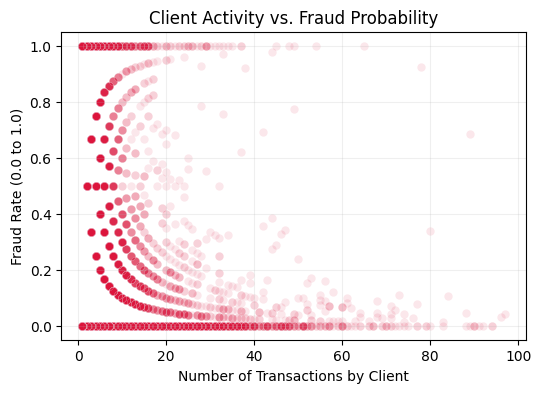

In [8]:
plt.figure(figsize=(6, 4))
sns.scatterplot(data=client_stats[client_stats['Trans_Count'] < 100],
                x='Trans_Count', y='Fraud_Rate', alpha=0.1, color='crimson')
plt.title('Client Activity vs. Fraud Probability')
plt.xlabel('Number of Transactions by Client')
plt.ylabel('Fraud Rate (0.0 to 1.0)')
plt.grid(True, alpha=0.2)
plt.show()

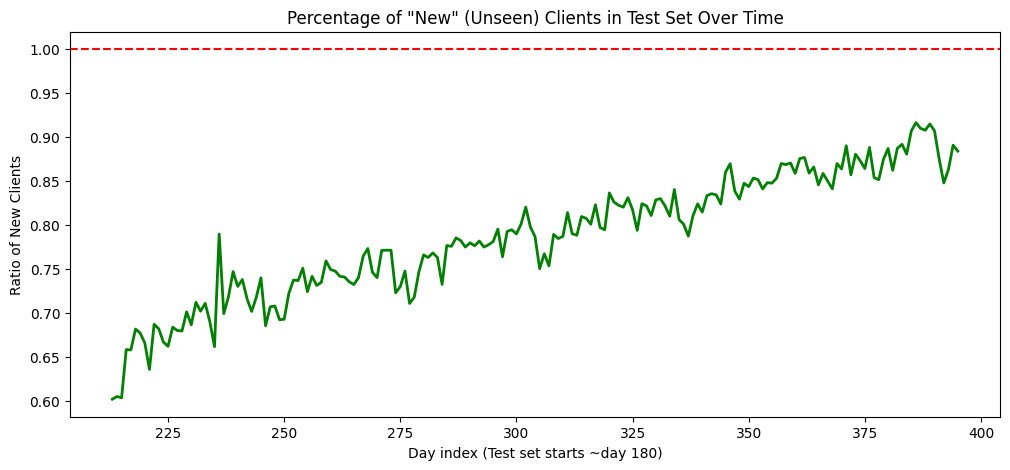

In [9]:
# Mark which UIDs are in Train
train_uids = set(train_df['UID'].unique())

# Check Test UIDs
test_df['is_new_client'] = ~test_df['UID'].isin(train_uids)

# Plot "New vs Old" clients in the Test Set over time
test_df['day'] = (test_df['TransactionDT'] / 86400).astype(int)
new_client_trend = test_df.groupby('day')['is_new_client'].mean()

plt.figure(figsize=(12, 5))
new_client_trend.plot(color='green', linewidth=2)
plt.title('Percentage of "New" (Unseen) Clients in Test Set Over Time')
plt.ylabel('Ratio of New Clients')
plt.xlabel('Day index (Test set starts ~day 180)')
plt.axhline(y=1.0, color='r', linestyle='--')
plt.show()

In [10]:
transaction_categorical_features = ['ProductCD', 'card1', 'card2', 'card3', 'card4', 'card5', 'card6', 'addr1', 'addr2', 'P_emaildomain', 'R_emaildomain', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9']
identity_categorical_features = ['DeviceType', 'DeviceInfo', 'id_12', 'id_13', 'id_14', 'id_15', 'id_16', 'id_17', 'id_18', 'id_19', 'id_20', 'id_21', 'id_22', 'id_23', 'id_24', 'id_25', 'id_26', 'id_27', 'id_28', 'id_29', 'id_30', 'id_31', 'id_32', 'id_33', 'id_34', 'id_35', 'id_36', 'id_37', 'id_38']